
## Credit statement:
This notebook was created by Professor [Sebastien Motsch](https://search.asu.edu/profile/2223626) at Arizona State University for his class (APM598: Introduction to deep neural networks) in 2020.

The goal of this notebook is to get familiar with *sequencial* data-sets. We start by looking at time series (i.e. sequence of numbers or vectors) and present Auto-Regressive model to make (simple) predictions. Then we discuss n-gram model used for analyzing *text*. We finish by briefly discussing *vanilla* Recurrent Neural Networks (RNN).


## Auto-Regressive model
We suppose that the input is given as a sequence of scalars: $x_1,x_2,\dots,x_t$ with $x_t\in \mathbb{R}$. The goal is to predict the next value $x_{t+1}$, we denote our prediction $\hat{y}_t$.

<div>
<img src="figures/AR_time_series.png" width="800"/>
</div>


In a auto-regressive model, we suppose that $x_{t+1}$ is approximated by a linear combination of the $n$ previous values:

$$x_{t+1} \approx a_0\cdot x_t +  a_1\cdot x_{t-1} + \dots + a_{n-1}\cdot x_{t-(n-1)} + b.$$

With this assumption, our prediction $\hat{y}_t$ is a linear model with $n+1$ parameters: $θ=\{a_0,\dots,a_{n-1},b\}$. Let's give an example by generating 'synthetic data' (a sinusoid with some noise).

In [18]:
import numpy as np
# generate "synthetic" data
t = np.arange(0,50)
x = np.sin(t) + .1*np.random.randn(50)
# split
x_train,x_test = x[:30],x[30:]

We use the library *statsmodel* to estimate the parameters $θ$ (i.e. minimizing the mean-square error: $\sum_t |\hat{y}_t-x_{t+1}|$).

In [19]:
from statsmodels.tsa.ar_model import AR
# define the model
model_AR = AR(x_train)
# fit the model with a windows n=2
myModel = model_AR.fit(maxlag=2)
b,a0,a1 = myModel.params
print("-- parameters: ")
print("b,a0,a1 = ",b,a0,a1)
# dir(myModel)

-- parameters: 
b,a0,a1 =  -0.005408355245650184 1.0317061353990282 -0.9755074233542368


The model can be used to make predictions:

  1. we initialize at the last points $x_{t-1}=x_{28}$ and $x_{t}=x_{29}$, 
  
  2. make a prediction: $\hat{y}_t = a_0 x_t + a_1 x_{t-1}+b$
  
  3. re-initialize: $x_{t-1}=x_t,\,x_t=\hat{y}_t$ and loop in step 1.



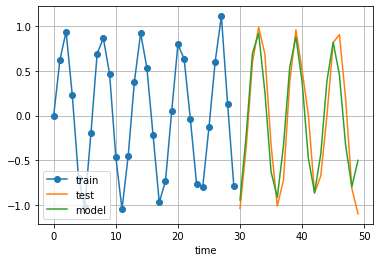

In [20]:
import matplotlib.pyplot as plt
# prediction
y_prediction = np.zeros(20)
x_tm1,x_t = x_train[28],x_train[29]
for k in range(20):
    # prediction t+1
    y = a0*x_t + a1*x_tm1 + b
    # save
    y_prediction[k] = y
    x_tm1,x_t = x_t,y
# plot    
plt.figure(1);plt.clf()
plt.plot(range(30),x_train,'-o',label='train')
plt.plot(range(30,50),x_test,label='test')
plt.plot(range(30,50),y_prediction,label='model')
plt.xlabel('time')
plt.legend()
plt.grid()
plt.draw()

## n-gram models



### Introduction



We would like to use a similar strategy as Auto-Regressive model to predict new words in a sentence. Let's give an example:

<center>the dog is  _?_ </center>

We are given three words $x_1="the"$, $x_2="dog"$, $x_3="is"$ and the goal is to predict the fourth word $x_4$. The major difference with Auto-Regressive model is that the input sentence is no longer a list of scalars (or vectors) thus we can add or multiply (i.e. $a_0*x_t+a_1*x_{t-1}$ has no meaning).

Instead of 'predicting' *one* word $\hat{y}_t$, we propose a model that can predict *any* words $x$, i.e. $\hat{Y}_t$ is now a random variable. We want $\hat{Y}_t$ to give more *frequently* a word $x$ that occurs frequently in our data-set. More precisely, we would like:

<center> $\mathbb{P}(\hat{Y}_t=x|x_t,x_{t-1},\dots, x_1) = \mathbb{P}(x_{t+1}=x|x_t,x_{t-1},\dots, x_1)$</center>

where $\mathbb{P}(A|B)$ means the probability of event $A$ knowing that $B$ happens.

In a 'n-gram' model, we assume that the probability that $x_{t+1}$ occurs only depends only on the $(n-1)$ previous words ($n$ is a fixed window size), i.e.

<center> $\mathbb{P}(x_{t+1}|x_t,x_{t-1},\dots, x_1) \approx \mathbb{P}(x_{t+1}|x_t,x_{t-1},\dots, x_{t-(n-1)})$ </center>

To estimate this probability, we use the formula $\mathbb{P}(A|B)=\frac{\mathbb{P}(A\cap B)}{\mathbb{P}(B)}$:

<center> $\mathbb{P}(x|x_t,x_{t-1},\dots, x_{t-(n-1)}) = \frac{\#\{(x_{t-(n-1)},\dots,x_t,x)\}}{\#\{(x_{t-(n-1)},\dots,x_t)\}}$ </center>

where $\#\{...\}$ counts the number of occurences of a given tuples.

**Ex.** In a bigram model (n=1), to estimate the probability that the word 'the' is followed by 'dog' (i.e. $\mathbb{P}(x_{t+1}="dog"|x_t="the"$), we first count in the data-set (i.e. the long sequence $(x_1,\dots,x_N)$) how many occurences of $("the","dog")$ appears, then counts the number of occurences of the single word $("the")$. The probability that we are looking for is the ratio between the two numbers.


### Tokenize and uni-gram
To estimate the probability defined previously, we need to count the number of occurences of *tuples* $(x_{t-(n-1)},\dots,x_t)$. The first step is to decompose a long sentence (one string) into a list of single word. This operation is called *tokenizing*.

Let's give an example using the module 'nltk'. First we load a (long) text as a string. We use for that the book 'Discourse on the Method' by Descartes (file attached):

In [1]:
with open('data/Descartes.txt', 'r') as myfile:
    myText = myfile.read().replace('\n',' ')
print(myText[0:44])
type(myText)

If this Discourse appear too long to be read


str

We then tokenize the text into words:



In [2]:
import nltk
# nltk.download('punkt')
# nltk.download()
# OSX: /usr/local/share/nltk_data/tokenizers
# nltk.data.path.append("/usr/local/share/nltk_data")
nltk.data.path.append("data/nltk_data")
myText_tokenized = nltk.word_tokenize(myText)
print(myText_tokenized[0:10])
print("-- length of texts (words) : ",len(myText_tokenized))

['If', 'this', 'Discourse', 'appear', 'too', 'long', 'to', 'be', 'read', 'at']
-- length of texts (words) :  25398


Then we can compute the uni-gram (frequency of one word) and deduce the most frequent words in the text:



In [4]:
myUnigram = nltk.ngrams(myText_tokenized, 1)
fdist_uni = nltk.FreqDist(myUnigram)
print("The 10 most frequent words:\n")
print(fdist_uni.most_common()[0:10])

The 10 most frequent words:

[((',',), 1766), (('the',), 1379), (('of',), 965), (('to',), 940), (('and',), 634), (('I',), 610), (('that',), 609), (('in',), 591), (('which',), 344), (('it',), 309)]


The object *fdist_uni* is a sort of *advanced* dictionary. We can access the words (*fdist_uni.keys()*) and their associated frequency (*fdist_uni.values()*) in the following ways:

In [5]:
print("-- frequence of the word 'think' : ",fdist_uni[('think',)])    # input must be a one-tuple ('...',) 
print("-- total number of words : ",sum(fdist_uni.values()))

-- frequence of the word 'think' :  19
-- total number of words :  25398


### Bi-gram

In a bigram, we count the occurences of the *pairs* $(x_t,x_{t+1})$. We use once again the nltk library to estimate these occurences.

In [6]:
myBigram = nltk.ngrams(myText_tokenized, 2)
fdist_bi = nltk.FreqDist(myBigram)
print("Occurences of 'I think': ",fdist_bi[('I','think')])
print("The 10 most frequent coupled words:\n")
print(fdist_bi.most_common()[0:10])

Occurences of 'I think':  9
The 10 most frequent coupled words:

[((',', 'and'), 286), (('of', 'the'), 224), ((',', 'I'), 162), (('in', 'the'), 152), (('to', 'the'), 97), ((',', 'that'), 96), ((';', 'and'), 94), ((',', 'as'), 86), (('that', 'I'), 80), ((',', 'in'), 79)]


Having a unigram and bigram, we deduce the probability: $\mathbb{P}(x_{t+1}|x_t) = \frac{\#\{(x_t,x_{t+1})\}}{\#\{(x_t)\}\}}$.

In [7]:
print("-- probability to have 'think' after 'I' :", fdist_bi[('I','think')] / fdist_uni[('I',)])

-- probability to have 'think' after 'I' : 0.014754098360655738


## Generating text
We are now ready to generate text using a bi-gram model. Starting from a given word $x_1$, we can generate a sequence $x_2,x_3,...$ by generating a *Markov chain* with transition probabilities $\mathbb{P}(x_{t+1}|x_t)$ estimated previously. The algorithm is summarized as follow:

  1. Starting from $x_1$, find all the possible *next* words $y$ (i.e. $\mathbb{P}(y|x_1)\neq 0$). Denote $\mathcal{N}$ this ensemble of words.
  2. Collect all the probabilities $p_k = \mathbb{P}(y_k|x_1)$ for $y_k\in \mathcal{N}$.
  3. Pick one $y_k$ with probability $p_k$ and set $x_2$.
  4. Go back to 1 starting from $x_2$.
  
Let's start by combining steps 1 to 3.

In [9]:
import pandas as pd    
import numpy as np

def pick_index(p):
    ''' Return one index from the array p with 
          Prob('pick index'=k) = p[k]
    '''
    cdf = np.cumsum(p)
    return sum(np.random.rand()*cdf[-1] > cdf)

def pick_next_word(fdist_bi,x):
    ''' use a bi-gram to find the next word
        The probability to pick a word is 'proportional' to its frequency.
        Moreover, we only consider couple of words with frequency at least 2:
            (x,y) should happen at least twice in the training set for y to be
            a potential next word.
    '''
    # initialize
    df = pd.DataFrame(columns=('nextWord', 'frequency'))
    # go over all the bi-gram
    for words,freq in fdist_bi.items():
        if (words[0]==x) and (freq > 1):
            df.loc[len(df)] = (words[1],freq)   # add a new potential next word
    # pick one
    if (len(df) > 0):
        count = df['frequency'].values.astype('int')
        index = pick_index(count)
        return df['nextWord'][index]
    else:
        return '----------'

We can give a try starting from the word 'I':

In [12]:
print( pick_next_word(fdist_bi,'I') )
print( pick_next_word(fdist_bi,'I') )
print( pick_next_word(fdist_bi,'I') )

esteemed
will
observed


It remains to 'loop' by predicting the 'next next' word based on our previous prediction:

In [15]:
print('-- Example of generated text --')
x_t = 'I'
theSentence = x_t
for k in range(15):
    x_t = pick_next_word(fdist_bi,x_t)
    theSentence += ' '+x_t
print(theSentence)

-- Example of generated text --
I will find in it not necessary to imagine the blood , without light , I


We can *tune* the transition probability. For instance, selecting only the *most* frequent next work, i.e. 


$$\mathbb{P}(x|x_t)=\left\{ \begin{array}{ll}
  1 & \text{if } x \text{ most likely word after } x_t\\
  0 & \text{otherwise}
\end{array}\right.$$

In [16]:
def pick_next_word_mostLikely(fdist_bi,x):
    ''' use a bi-gram to find the next word.
        We pick the word with highest frequency:
           y_t = argmax_x P(x|x_t)
        where P(x|x_t) is the probability to have x as a next word after x_t.
    '''
    # initialize
    freq_best = 0
    y = '_'
    # go over all the bi-gram
    for words,freq in fdist_bi.items():
        if (words[0]==x) and (freq>freq_best):
            freq_best = freq
            y = words[1]
    return y

We can give a try starting from the word 'I':



In [21]:
print('-- Example of generated text (deterministic) --')
x_t = 'I'
theSentence = x_t
for k in range(15):
    x_t = pick_next_word_mostLikely(fdist_bi,x_t)
    theSentence += ' '+x_t
print(theSentence)

-- Example of generated text (deterministic) --
I had been in the heart , and that I had been in the heart ,


The prediction quickly becomes periodic. 

## Vanilla RNN



### Embeddings



We now turn to our main focus with Recurrent Neural Networks. We are limited with 'n-gram' as we cannot perform any *complex* manipulations that are allowed with vectors (i.e. addition, matrix-multiplication, applying non-linear functions). For that, we need first to *embed* words into vectors. A simpler way to do so is to assign for each unique word a 'hot-vector'. For instance, taking the sentence *"the cat is sleeping"*, we create vectors:
<center>
$\text{"the"}\, \hookrightarrow  \left(\begin{array}{c}
 1 \\
 0 \\
 0 \\
 0
 \end{array}\right), \; \; \text{"cat"}\, \hookrightarrow  \left(\begin{array}{c}
 0  \\
 1  \\
 0  \\
 0
 \end{array}\right), \; \; \text{"is"}\, \hookrightarrow  \left(\begin{array}{c}
 0  \\
 0  \\
 1  \\
 0
 \end{array}\right), \; \; \text{"sleeping"}\, \hookrightarrow  \left(\begin{array}{c}
 0  \\
 0  \\
 0  \\
 1
 \end{array}\right).$ </center>
Since we have $4$ unique words, we need to use the vector space $ℝ^4$. Thus, for a large text, we would need a vector space of dimension of order $10,000$. As a consequence, there are risks of overfitting. To avoid such problem, we have to use *word embeddings* (e.g. word2vec), but we leave this task for later.

Instead, we are going to simply try to predict the next **character** rather than the next **word**. The number of unique characters is of order $100$.



In [22]:
import string
ALL_LETTERS = string.ascii_letters + string.digits + " '.,;:!?-()\"" + '\n'
NB_LETTERS = len(ALL_LETTERS)
print("All the possible characters that we will use:")
print(ALL_LETTERS)

All the possible characters that we will use:
abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 '.,;:!?-()"



We can define our embedding: each character is assigned a unique hot-vector



In [23]:
import torch

def letterToIndex(letter):
    """ Find letter index from all_letters, e.g. "a" = 0 """
    return ALL_LETTERS.find(letter)

def letterToTensor(letter):
    """ Transform a letter into a 'hot-vector' (tensor) """
    #tensor = torch.zeros(1, NB_LETTERS,dtype=torch.long)
    tensor = torch.zeros(1, NB_LETTERS)
    tensor[0][letterToIndex(letter)] = 1
    return tensor
print("Embedding of the character 'c':")
letterToTensor('c')

Embedding of the character 'c':


tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])

### Introduction to RNN



Since we are now dealing with vectors, we can perform usual operations (e.g. matrix multiplication). The classic architecture for recurrent neural network is based on three elements:

1. an 'encoder' denoted $A$
2. a 'decoder' denoted $B$
3. a 'recurrent matrix' $R$.

The prediction will be based on some 'internal' state 'h<sub>t</sub>', also called *hidden* state, that will be changing over *time*. The architecture is described in the following figure:

![Illustration of Recurrent-Neural-Network](figures/sketch_rnn_2.png)

Thus, the key quantity to define our RNN is the dimension of the hidden-space. Typically, its size should be smaller than the *input* space (hence the name 'encoder' from the matrix $A$ and 'decoder' from the matrix $B$).



In [24]:
import torch.nn as nn
class Vanilla_RNN(nn.Module):
    """
    The vanilla RNN: from (x_t,h_t-1) input,hidden-state
        h_t = tanh( R*h_t-1 + A*x_t)
        y_t = B*h_t
     where A is the encoder, B the decoder, R the recurrent matrix
    """
    def __init__(self, input_size, hidden_size, output_size):
        super(Vanilla_RNN, self).__init__()
        self.hidden_size = hidden_size
        self.A = nn.Linear(input_size, hidden_size) # input to hidden
        self.R = nn.Linear(hidden_size, hidden_size) # hidden to hidden
        self.B = nn.Linear(hidden_size, output_size) # hidden to output
        self.tanh = nn.Tanh()
    
    def forward(self, x, h):
        # update the hidden state
        h_update = self.tanh( self.R(h) + self.A(x) )
        # prediction
        y = self.B(h_update)
        return y,h_update

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

Notice that, in contrast to CNN, we have defined an extra function **init_hidden** (called *method* in the context of an object) that will initialize the hidden state *h*. We can first test the network: we initialize a RNN with internal dimension $25$ and feed it with a zero hidden state and the letter $T$.



In [25]:
# define a RNN
hidden_size = 25
in_out_size = NB_LETTERS
myRnn = Vanilla_RNN(in_out_size,hidden_size,in_out_size)
# test it
x_0 = letterToTensor('T')
h = myRnn.init_hidden()
y_0,h = myRnn(x_0,h)
print("input: ",'T')
predicted_char = ALL_LETTERS[y_0.argmax()]
print("output: ",predicted_char)

input:  T
output:  w


### Training RNN



We define a function that will train the RNN. As for a CNN, we will use the cross-entropy loss. The output of the training will be the evolution of the loss after each 'step'. A step consists in taking a sentence of a fixed length, denoted *'chunk'*, from the main-text and compare it with the prediction of our RNN:

1. pick *'chunk'* from main text and initiate $h_0$
2. for each letter $x_t$ in 'chunk':
    1. predict the next letter $y_t=Rnn(h_t,x_t)$
    2. estimate the cross-entropy $H(x_{t+1},y_t)$
3. back-propagate (gradient-descent) to update the parameters (i.e. $A,\,B,\,C$)



In [26]:
import random

def train_RNN(myRnn,myText,P,shouldPrintTraining=False):
    """
    Train a recurrent neural network from a text ('myText'). The dictionary P
    should contain:
       . the learning rate 'lr'
       . the number of steps 'n_steps'
       . the size of the sentence trained on 'chunk_len'
    """
    # init
    optimizer = torch.optim.Adam(myRnn.parameters(), lr=P['lr'])
    criterion = nn.CrossEntropyLoss()
    df = pd.DataFrame(columns=('step', 'loss'))
    # train
    for step in range(P['n_steps']):
        # A) initialize
        h = myRnn.init_hidden()
        optimizer.zero_grad()
        loss = 0.0
        # B) pick a chunk from the text
        start_index = random.randint(0, len(myText) - P['chunk_len'])
        end_index = start_index + P['chunk_len'] + 1
        chunk = myText[start_index:end_index]
        if (shouldPrintTraining) & (step%50 == 0):
            print(" input  = ", chunk)
            chunk_predicted = chunk[0]
        # C) prediction
        for p in range(P['chunk_len']-1):
            # init
            x = letterToTensor( chunk[p] )
            #x_next = letterToTensor( chunk[p+1] )
            letter_x_next = letterToIndex(chunk[p+1])
            #print(chunk[p+1])
            #print(letter_x_next)
            target = torch.tensor([letter_x_next],dtype=torch.long)
            # prediction
            y, h = myRnn(x, h)
            # loss
            loss += criterion(y.view(1,-1), target)
            if (shouldPrintTraining):
                chunk_predicted += ALL_LETTERS[y.argmax()]
        # D) gradient step
        loss.backward()
        optimizer.step()
        # E) save loss
        ave_loss = loss.detach().numpy() / P['chunk_len']
        if (shouldPrintTraining) & (step%50 == 0):
            print(" output = ", chunk_predicted)
        df.loc[step] = [step, ave_loss]
        if (step%50 == 0):
            # print only once every 50 steps
            print('loss at step ',str(step),' : ', str(ave_loss))
    # result
    return df


# We can train the network and compare the prediction $y_t$ with $x_{t+1}$ at different steps.


P = {'n_steps' : 1000,
     'lr' : .005,
     'chunk_len' : 30}
df = train_RNN(myRnn,myText,P,True)

 input  =  he ground of our opinions, I re
 output =  hgJgooHoowggHgHogggHoHoHggogog
loss at step  0  :  4.1553326
 input  =  tify me if they be examined, an
 output =  th                            
loss at step  50  :  2.9491565
 input  =  s, and of which we cannot remai
 output =  s                             
loss at step  100  :  2.6945956
 input  =  tunity of adding something on t
 output =  t      tt tt  t  t     et  tt 
loss at step  150  :  2.6318762
 input  =  y of which I was in search.  In
 output =  y tn theteet tht tn t  teee tt
loss at step  200  :  2.711411
 input  =  annot be useful to some without
 output =  an    te tn   t thet    thnhen
loss at step  250  :  2.6189778
 input  =   well aware that it cannot serv
 output =   th   tn te then an aen    ae 
loss at step  300  :  2.2741995
 input  =  thinner, and rarefies more read
 output =  thet   e tn  tene  t  aene te 
loss at step  350  :  2.1403697
 input  =   give us no adequate criterion 
 output =   thne to to tn

We observe that the network first start to predict only spaces as it is the most common characters. Thus, the network reaches first a 'local' minimum. To further illustrate this property, let's estimate what are the frequency of each characters using a 'uni-gram'.

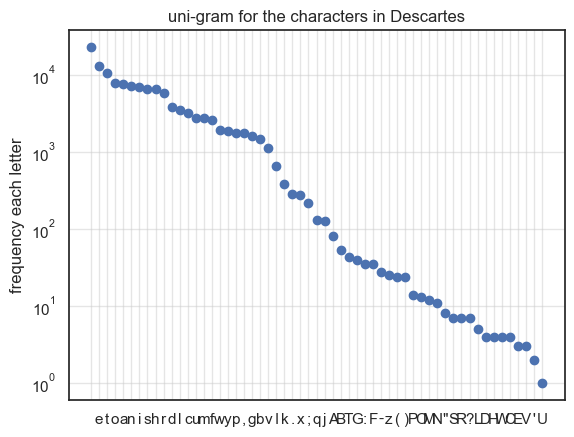

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

myUnigrams = nltk.ngrams(myText, 1)
fdist_uni = nltk.FreqDist(myUnigrams)
sorted_x = sorted(fdist_uni.items(), key=lambda x: x[1],reverse=True)
distri_letters = [sorted_x[k][1] for k in range(len(sorted_x))]
corresponding_letters = [sorted_x[k][0][0] for k in range(len(sorted_x))]
plt.figure(1);plt.clf()
#plt.plot(distri_letters,'o')
plt.semilogy(distri_letters,'o')
plt.grid()
plt.xticks(range(len(sorted_x)), corresponding_letters)
plt.ylabel("frequency each letter")
plt.title("uni-gram for the characters in Descartes")
plt.show()

After the local minimum has been reached, the network starts to predict some patterns such as *"th"*. The evolution of the loss shows that predicting text is a more delicate task than classification.

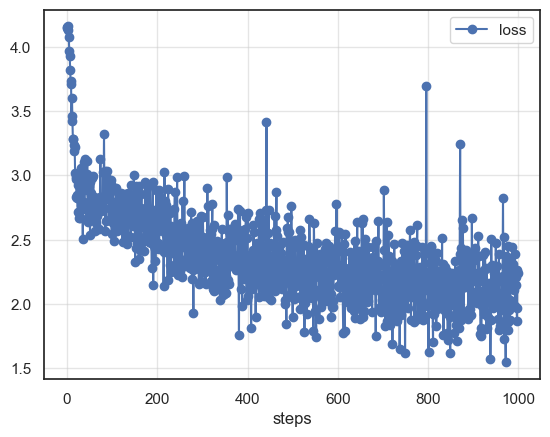

In [30]:
plt.figure(2);plt.clf()
plt.plot(df['step'],df['loss'],'-o')
#plt.axis([0, P['numStep'], 0, 1])
plt.grid()
plt.xlabel('steps')
plt.legend(['loss'])
plt.show()

The loss starts around $4.3$ which corresponds to $-\log(NB_letter)=-\log(75)\approx 4.317$, i.e. the network initially gives the same probability for each letter. Then, in a first phase, the loss quickly decays up to around $3$, in the second phase the overall decay is much slower. Notice that since we are not using mini-batch, we do not average over many predictions which explains why the loss is sometimes completely off.